In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Image
from reportlab.lib.styles import ParagraphStyle
from reportlab.lib import colors
from reportlab.lib.units import inch
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.platypus import Image as RLImage
import os

sns.set(style="whitegrid")

In [4]:
df = pd.read_csv("NetFlix.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,14-Aug-20,2020,TV-MA,4,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s10,Movie,1920,Vikram Bhatt,"Rajneesh Duggal, Adah Sharma, Indraneil Sengup...",India,15-Dec-17,2008,TV-MA,143,"Horror Movies, International Movies, Thrillers",An architect and his wife move into a castle t...
2,s100,Movie,3 Heroines,Iman Brotoseno,"Reza Rahadian, Bunga Citra Lestari, Tara Basro...",Indonesia,5-Jan-19,2016,TV-PG,124,"Dramas, International Movies, Sports Movies",Three Indonesian women break records by becomi...
3,s1000,Movie,Blue Mountain State: The Rise of Thadland,Lev L. Spiro,"Alan Ritchson, Darin Brooks, James Cade, Rob R...",United States,1-Mar-16,2016,R,90,Comedies,New NFL star Thad buys his old teammates' belo...
4,s1001,TV Show,Blue Planet II,NaN,David Attenborough,United Kingdom,3-Dec-18,2017,TV-G,1,"British TV Shows, Docuseries, Science & Nature TV",This sequel to the award-winning nature series...


In [8]:
print(df.info())
print("\nMissing Values:\n", df.isnull().sum())


df['country'].fillna("Unknown", inplace=True)
df['director'].fillna("Unknown", inplace=True)
df.dropna(subset=['date_added'], inplace=True)


df['date_added'] = pd.to_datetime(df['date_added'])
df['year_added'] = df['date_added'].dt.year

<class 'pandas.core.frame.DataFrame'>
Index: 7777 entries, 0 to 7786
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       7777 non-null   object        
 1   type          7777 non-null   object        
 2   title         7777 non-null   object        
 3   director      7777 non-null   object        
 4   cast          7059 non-null   object        
 5   country       7777 non-null   object        
 6   date_added    7777 non-null   datetime64[ns]
 7   release_year  7777 non-null   int64         
 8   rating        7770 non-null   object        
 9   duration      7777 non-null   int64         
 10  genres        7777 non-null   object        
 11  description   7777 non-null   object        
 12  year_added    7777 non-null   int32         
dtypes: datetime64[ns](1), int32(1), int64(2), object(9)
memory usage: 820.2+ KB
None

Missing Values:
 show_id           0
type              0
titl

C:\Users\arthi\AppData\Local\Temp\ipykernel_27696\4032325167.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['country'].fillna("Unknown", inplace=True)
C:\Users\arthi\AppData\Local\Temp\ipykernel_27696\4032325167.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exampl

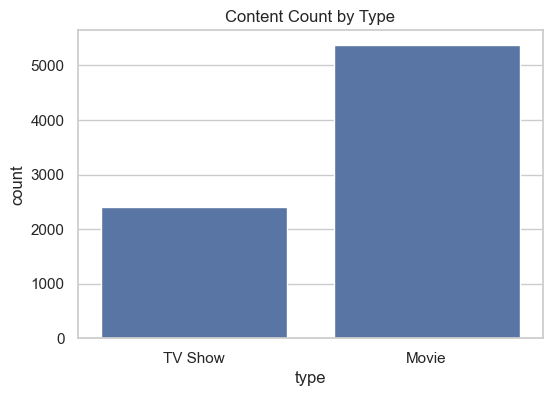

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(x='type', data=df)
plt.title("Content Count by Type")
plt.savefig("type_count.png")
plt.show()

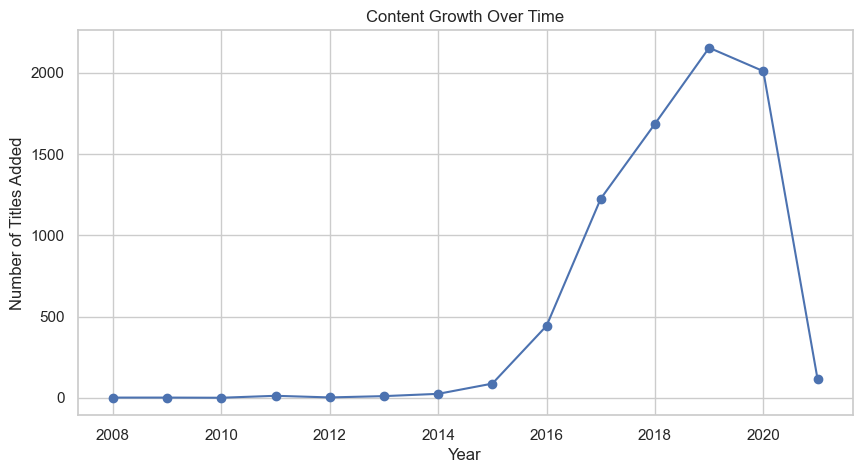

In [10]:
yearly_growth = df['year_added'].value_counts().sort_index()

plt.figure(figsize=(10,5))
yearly_growth.plot(kind='line', marker='o')
plt.title("Content Growth Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Titles Added")
plt.savefig("growth_over_time.png")
plt.show()

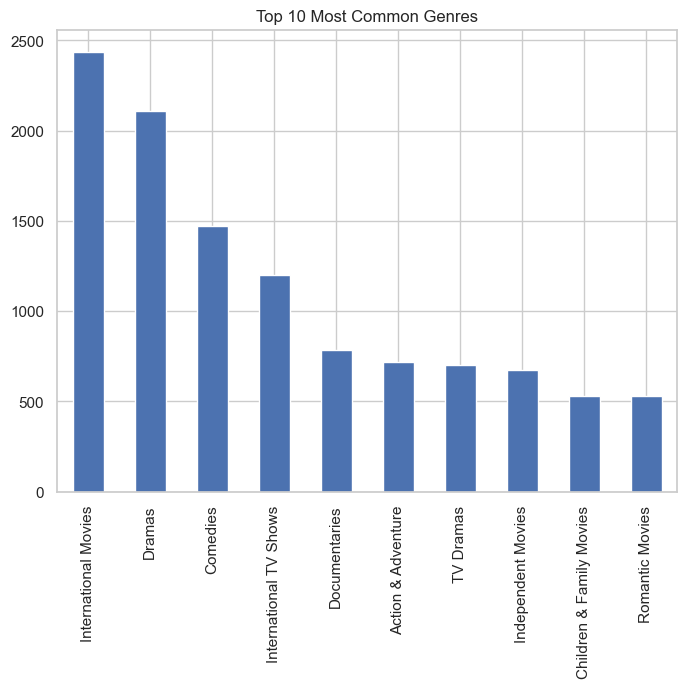

Top 10 Genres:
 International Movies        2437
Dramas                      2106
Comedies                    1471
International TV Shows      1198
Documentaries                786
Action & Adventure           721
TV Dramas                    703
Independent Movies           673
Children & Family Movies     532
Romantic Movies              531
Name: count, dtype: int64


In [12]:
genres = df['genres'].str.split(', ', expand=True).stack()
top_genres = genres.value_counts().head(10)

plt.figure(figsize=(8,6))
top_genres.plot(kind='bar')
plt.title("Top 10 Most Common Genres")
plt.savefig("top_genres.png")
plt.show()

print("Top 10 Genres:\n", top_genres)

C:\Users\arthi\AppData\Local\Temp\ipykernel_27696\323103483.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movies['duration_int'] = movies['duration'].replace(" min","").astype(int)


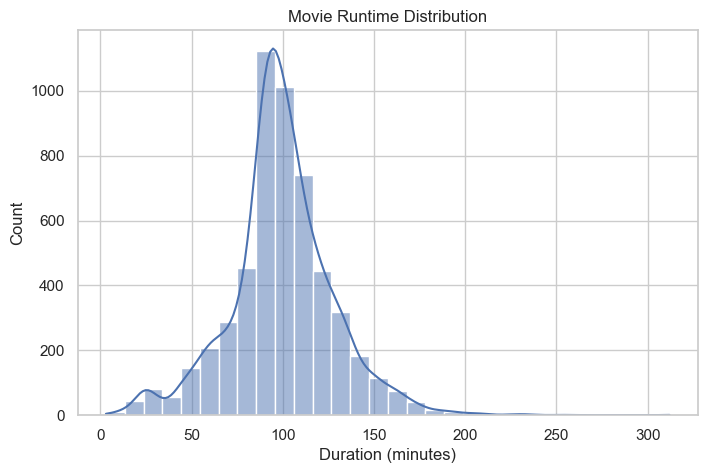

In [18]:
movies = df[df['type'] == 'Movie']
movies['duration_int'] = movies['duration'].replace(" min","").astype(int)

plt.figure(figsize=(8,5))
sns.histplot(movies['duration_int'], bins=30, kde=True)
plt.title("Movie Runtime Distribution")
plt.xlabel("Duration (minutes)")
plt.savefig("runtime_distribution.png")
plt.show()

In [19]:
top_years = df['year_added'].value_counts().head(10)
print("Top 10 Years:\n", top_years)

Top 10 Years:
 year_added
2019    2153
2020    2009
2018    1685
2017    1225
2016     443
2021     117
2015      88
2014      25
2011      13
2013      11
Name: count, dtype: int64


In [20]:
doc = SimpleDocTemplate("Netflix_EDA_Report.pdf")
elements = []

styles = getSampleStyleSheet()

elements.append(Paragraph("<b>Netflix Dataset EDA Report</b>", styles["Title"]))
elements.append(Spacer(1, 0.5 * inch))

summary_text = """
Key Findings:
1. Movies dominate the platform compared to TV Shows.
2. Content growth significantly increased after 2015.
3. Drama and International Movies are top genres.
4. Most movies range between 80-120 minutes.
5. Peak content addition year shows rapid expansion strategy.
"""

elements.append(Paragraph(summary_text, styles["Normal"]))
elements.append(Spacer(1, 0.5 * inch))

# Add saved images
for image_file in ["type_count.png", "growth_over_time.png", "top_genres.png", "runtime_distribution.png"]:
    if os.path.exists(image_file):
        elements.append(RLImage(image_file, width=5*inch, height=3*inch))
        elements.append(Spacer(1, 0.3 * inch))

doc.build(elements)

print("PDF Report Generated Successfully!")

PDF Report Generated Successfully!
